# Arctic Nuclear Necessity: A Data-Driven Case for Micro-Reactors
**Author:** [Your Name]  
**Date:** [Today's Date]  
**Position:** STEM Intern Candidate — Canadian Strategic Missions Corporation (CSMC)  
**Data Sources:** NASA POWER Climate Database · Statistics Canada 2021 Census · NRCan Arctic Energy Profiles

---

## Project Overview

This analysis quantifies the Arctic renewable energy gap across Northern Canada using 10 years of climate data and sizes a micro-nuclear reactor solution for five remote communities. Every step is documented with methodology rationale to demonstrate analytical rigour expected in a defence and nuclear engineering environment.

### Job Description Skills Demonstrated
| This Notebook | CSMC Role Requirement |
|---|---|
| Structured data pipeline with documented methodology | Technical documentation management |
| RERS metric development + trend analysis | Data analysis to identify patterns |
| 4 publication-quality charts | Technical presentations for stakeholders |
| 7-risk register with mitigations | Risk tracking with proposed solutions |
| Reactor sizing model | Support for design processes |
| This project log structure | Accurate project documentation |

---

## Section 1: Environment Setup & Data Loading

**Why this step:** Before any analysis, we establish a reproducible environment with documented dependencies. In a defence/nuclear engineering context, every result must be reproducible by a third party — this is not optional, it is standard practice for audit and verification purposes.


In [128]:
# Standard scientific Python stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0A0E14',
    'axes.facecolor':   '#0A0E14',
    'text.color':       '#DDE3EE',
    'axes.labelcolor':  '#8899AA',
    'xtick.color':      '#8899AA',
    'ytick.color':      '#8899AA',
})

print("Environment ready. Library versions:")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")

Environment ready. Library versions:
  pandas  1.5.3
  numpy   1.26.4


### 1.1 Loading the Climate Dataset

**Data source:** NASA POWER (Prediction Of Worldwide Energy Resources) — a publicly accessible NASA database providing satellite-derived surface meteorological data globally since 1981.

**Why NASA POWER:** It is the standard reference dataset used by renewable energy engineers worldwide for site assessment. Using it here directly mirrors how CSMC would assess potential micro-reactor deployment sites before committing capital.

**Location selected:** 68°N, 110°W — representative of Canada's high Arctic, overlapping with Nunavut/NWT communities that are primary candidates for micro-reactor deployment.

**To download real data yourself:** Visit [power.larc.nasa.gov](https://power.larc.nasa.gov) and use the API call documented in `README.md`.


In [129]:
import requests
import pandas as pd

def pull_nasa_power(lat, lon, start="2015", end="2024"):
    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,WS10M,T2M",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"       # <-- JSON instead of CSV
    }
    response = requests.get(url, params=params, timeout=30)
    print(f"NASA POWER status: {response.status_code}")

    data = response.json()
    param_data = data["properties"]["parameter"]

    # Each parameter is a dict like {"202001": 3.45, "202002": 4.12, ...}
    rows = []
    solar = param_data["ALLSKY_SFC_SW_DWN"]
    wind  = param_data["WS10M"]
    temp  = param_data["T2M"]

    for key in solar:
        if len(key) == 6:  # "YYYYMM" format, skip annual "YYYY13" rows
            year  = int(key[:4])
            month = int(key[4:])
            if month <= 12:
                rows.append({
                    "year": year,
                    "month": month,
                    "solar_kwh_m2_day": solar[key],
                    "wind_ms": wind[key],
                    "temp_c": temp[key]
                })

    df = pd.DataFrame(rows)
    df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
    return df

climate = pull_nasa_power(lat=68, lon=-110)
print(f"\nRows pulled: {len(climate)}")
print(f"Years: {climate.year.min()} to {climate.year.max()}")
print(climate.head(12))

NASA POWER status: 200

Rows pulled: 120
Years: 2015 to 2024
    year  month  solar_kwh_m2_day  wind_ms  temp_c       date
0   2015      1            0.0228     6.89  -25.83 2015-01-01
1   2015      2            0.4375     6.20  -25.65 2015-02-01
2   2015      3            2.4506     5.11  -22.02 2015-03-01
3   2015      4            4.6483     4.50  -14.00 2015-04-01
4   2015      5            6.9499     4.43   -2.55 2015-05-01
5   2015      6            5.8308     4.96    4.34 2015-06-01
6   2015      7            4.7602     3.87    7.97 2015-07-01
7   2015      8            3.4342     5.31    9.31 2015-08-01
8   2015      9            1.9030     5.60    2.42 2015-09-01
9   2015     10            0.7169     5.72   -7.97 2015-10-01
10  2015     11            0.0660     5.31  -17.77 2015-11-01
11  2015     12            0.0000     4.35  -25.31 2015-12-01


In [130]:
def get_coordinates(place_name):
    url = "https://geogratis.gc.ca/services/geoname/en/geonames.json"
    params = {
        "q": place_name,
        "theme": 985,   # populated places only
        "num": 5
    }
    response = requests.get(url, params=params, timeout=30)
    items = response.json().get("items", [])
    
    if not items:
        print(f"No results found for {place_name}")
        return None
    
    print(f"\nMatches for {place_name}:")
    for item in items:
        province = item.get("province", {}).get("code", "")
        print(f"  {item['name']} {province} "
              f"— lat: {item['latitude']} lon: {item['longitude']}")
    
    # Take the first match
    # Review the printed matches above to confirm it is correct
    best = items[0]
    return {
        "name": best["name"],
        "lat": best["latitude"],
        "lon": best["longitude"]
    }

# Pull coordinates for each community from NRCan GeoNames
community_names = [
    "Iqaluit",
    "Inuvik",
    "Resolute",
    "Yellowknife",
    "Whitehorse"
]

coords_list = []
for name in community_names:
    result = get_coordinates(name)
    if result:
        coords_list.append(result)

coords_df = pd.DataFrame(coords_list)
print("\nCoordinates pulled from NRCan GeoNames:")
print(coords_df.to_string(index=False))


Matches for Iqaluit:
  Iqaluit 62 — lat: 63.75 lon: -68.516667

Matches for Inuvik:
  Inuvik 61 — lat: 68.3609 lon: -133.7297

Matches for Resolute:
  Resolute 62 — lat: 74.695833 lon: -94.829167

Matches for Yellowknife:
  Yellowknife 61 — lat: 62.4536 lon: -114.37

Matches for Whitehorse:
  Whitehorse 60 — lat: 60.7242144 lon: -135.0560981

Coordinates pulled from NRCan GeoNames:
       name       lat         lon
    Iqaluit 63.750000  -68.516667
     Inuvik 68.360900 -133.729700
   Resolute 74.695833  -94.829167
Yellowknife 62.453600 -114.370000
 Whitehorse 60.724214 -135.056098


In [131]:
import zipfile

def pull_statscan_population(communities):
    # Table 98-10-0002: Population and dwelling counts
    # Census subdivisions level (individual communities)
    url = "https://www150.statcan.gc.ca/n1/tbl/csv/98100002-eng.zip"
    
    print("Downloading Statistics Canada 2021 Census table...")
    response = requests.get(url, timeout=120)
    print(f"Stats Canada status: {response.status_code}")
    
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        csv_file = [
            f for f in z.namelist()
            if f.endswith(".csv") and "MetaData" not in f
        ][0]
        print(f"Reading file: {csv_file}")
        with z.open(csv_file) as f:
            census = pd.read_csv(f, encoding="latin-1")
    
    print(f"\nCensus table loaded — {len(census)} rows")
    print(f"Columns: {census.columns.tolist()}")
    print("\nSample GEO values:")
    print(census["GEO"].dropna().sample(10).tolist())
    
    return census

def extract_population(census, community_names):
    results = []

    # Find the population 2021 column (long transposed name)
    pop_col = [c for c in census.columns if "Population, 2021" in c][0]
    print(f"Using population column: {pop_col}")

    for name in community_names:
        matches = census[census["GEO"].str.contains(name, case=False, na=False)]
        if matches.empty:
            print(f"No match for {name}")
            continue

        print(f"\nAll matches for {name}:")
        print(matches[["GEO", pop_col]].to_string(index=False))

        best = matches.iloc[0]
        results.append({
            "search_name": name,
            "geo_name": best["GEO"],
            "population": int(float(best[pop_col]))
        })

    return pd.DataFrame(results)

census = pull_statscan_population(community_names)
population_df = extract_population(census, community_names)
print("\nPopulation pulled from Stats Canada:")
print(population_df.to_string(index=False))

Stats Canada status: 200
Reading file: 98100002.csv

Census table loaded — 5468 rows
Columns: ['ï»¿"REF_DATE"', 'GEO', 'DGUID', 'Coordinate', 'Population and dwelling counts (13): Population, 2021 [1]', 'Symbols', 'Population and dwelling counts (13): Population, 2016 [2]', 'Symbols.1', 'Population and dwelling counts (13): Population percentage change, 2016 to 2021 [3]', 'Symbols.2', 'Population and dwelling counts (13): Total private dwellings, 2021 [4]', 'Symbols.3', 'Population and dwelling counts (13): Total private dwellings, 2016 [5]', 'Symbols.4', 'Population and dwelling counts (13): Total private dwellings percentage change, 2016 to 2021 [6]', 'Symbols.5', 'Population and dwelling counts (13): Private dwellings occupied by usual residents, 2021 [7]', 'Symbols.6', 'Population and dwelling counts (13): Private dwellings occupied by usual residents, 2016 [8]', 'Symbols.7', 'Population and dwelling counts (13): Private dwellings occupied by usual residents percentage change, 2016

In [132]:
print("Names in population_df:", population_df["search_name"].tolist())
print("Names in coords_df:", coords_df["name"].tolist())

Names in population_df: ['Iqaluit', 'Inuvik', 'Resolute', 'Yellowknife', 'Whitehorse']
Names in coords_df: ['Iqaluit', 'Inuvik', 'Resolute', 'Yellowknife', 'Whitehorse']


In [133]:
sites = pd.merge(
    population_df,
    coords_df,
    left_on="search_name",
    right_on="name",
    how="inner"
)

sites["zone"] = sites["lat"].apply(
    lambda x: "High Arctic" if x >= 65 else "Subarctic"
)

print("Final sites table — all data from live sources:")
print(sites[["search_name", "population", "lat", "lon", "zone"]].to_string(index=False))

Final sites table — all data from live sources:
search_name  population       lat         lon        zone
    Iqaluit        7429 63.750000  -68.516667   Subarctic
     Inuvik        3137 68.360900 -133.729700 High Arctic
   Resolute         183 74.695833  -94.829167 High Arctic
Yellowknife       20340 62.453600 -114.370000   Subarctic
 Whitehorse       28201 60.724214 -135.056098   Subarctic


In [134]:
def pull_rced_baseline():
    url = (
        "https://geoappext.nrcan.gc.ca/arcgis/rest/services/"
        "FGP/remote_communities_2018_en/MapServer/0/query"
    )
    params = {
        "where": "1=1",
        "outFields": "*",
        "f": "json",
        "resultRecordCount": 1000
    }
    
    print("Downloading NRCan RCED from ArcGIS service...")
    response = requests.get(url, params=params, timeout=60)
    print(f"RCED status: {response.status_code}")
    
    data = response.json()
    features = data.get("features", [])
    print(f"Communities returned: {len(features)}")
    
    rows = [f["attributes"] for f in features]
    rced = pd.DataFrame(rows)
    
    print(f"\nRCED loaded — {len(rced)} rows")
    print(f"Columns: {rced.columns.tolist()}")
    print("\nFirst few rows:")
    print(rced.head())
    return rced

rced = pull_rced_baseline()

RCED status: 200
Communities returned: 276

RCED loaded — 276 rows
Columns: ['OBJECTID', 'COMMUNITYN', 'ALTERNATI1', 'PROVINCE_T', 'COMMUNITYR', 'COMMUNITYT', 'LATITUDE', 'LONGITUDE', 'COMMUNITYC', 'INDIGENOU1', 'ISTHEREYEA', 'ISTHISAFLY', 'POPULATION', 'MAINPOWERS', 'NAMEOFSERV', 'TOTALFFGEN', 'ANNUALFFGE', 'PRICEOFFUE', 'UNITS2', 'TOTALREGEN', 'COMMUNITYE']

First few rows:
   OBJECTID                COMMUNITYN        ALTERNATI1 PROVINCE_T  \
0         1  Les Îles-de-la-Madeleine  Magdalen Islands         QC   
1         2               Ocean Falls              None         BC   
2         3              Whitehorse 8              None         YT   
3         4               Bella Bella     Bella Bella 1         BC   
4         5                   Wagisla              None         BC   

                                   COMMUNITYR  COMMUNITYT   LATITUDE  \
0    Active > Multi-community local microgrid  Settlement  47.383330   
1    Active > Multi-community local microgrid  Settlemen

In [135]:
# Check what the  columns actually contain
print("MAINPOWERS values:")
print(rced["MAINPOWERS"].value_counts())

print("\nTOTALFFGEN sample (non-zero):")
print(rced[rced["TOTALFFGEN"].astype(float) > 0][["COMMUNITYN", "TOTALFFGEN", "ANNUALFFGE", "POPULATION"]].head(10))

print("\nANNUALFFGE sample (non-zero):")
print(rced[rced["ANNUALFFGE"].astype(float) > 0][["COMMUNITYN", "ANNUALFFGE"]].head(10))

print("\nColumn types:")
print(rced[["TOTALFFGEN", "ANNUALFFGE", "TOTALREGEN", "POPULATION"]].dtypes)

MAINPOWERS values:
Diesel              201
Hydro                35
Prov./terr. grid     26
Unknown               6
Natural Gas           4
Heavy fuel oil        3
Other                 1
Name: MAINPOWERS, dtype: int64

TOTALFFGEN sample (non-zero):
                  COMMUNITYN  TOTALFFGEN  ANNUALFFGE  POPULATION
0   Les Îles-de-la-Madeleine     67044.0   181648.00     12475.0
3                Bella Bella      4900.0      982.87      1019.0
6                Bella Coola      9250.0     7938.84       807.0
9                     Masset     13095.0    26433.00       793.0
13                  Sandspit     10150.0     5507.20       296.0
16               Anahim Lake      3550.0     6649.00        82.0
21                  Kwadacha      1800.0     2963.00       332.0
22            Good Hope Lake       622.0     1060.00         NaN
25                   Kulkayu      1095.0     1673.00        68.0
26                 Hesquiaht       150.0         NaN        44.0

ANNUALFFGE sample (non-zero):
     

In [136]:
# Filter to diesel communities in northern territories
arctic = rced[
    (rced["MAINPOWERS"] == "Diesel") &
    (rced["PROVINCE_T"].isin(["NU", "NT", "YT"]))
].copy()

print(f"Diesel Arctic communities found: {len(arctic)}")

# Drop rows missing generation or population
arctic = arctic.dropna(subset=["ANNUALFFGE", "POPULATION"])
arctic = arctic[arctic["POPULATION"] > 0]
arctic = arctic[arctic["ANNUALFFGE"] > 0]

print(f"With valid generation + population: {len(arctic)}")

# ANNUALFFGE is annual MWh — convert to daily kWh per person
arctic["daily_kwh_per_person"] = (
    arctic["ANNUALFFGE"] * 1000  # MWh to kWh
) / arctic["POPULATION"] / 365

print("\nDaily kWh per person by community:")
print(arctic[["COMMUNITYN", "POPULATION", "ANNUALFFGE", "daily_kwh_per_person"]]
      .sort_values("daily_kwh_per_person", ascending=False)
      .to_string(index=False))

DEMAND_BASELINE_KWH = arctic["daily_kwh_per_person"].median()
print(f"\nMedian demand baseline from RCED: {DEMAND_BASELINE_KWH:.1f} kWh/person/day")

Diesel Arctic communities found: 60
With valid generation + population: 53

Daily kWh per person by community:
          COMMUNITYN  POPULATION  ANNUALFFGE  daily_kwh_per_person
 Diavik Diamond Mine       330.0 174508416.0          1.448804e+06
Meadowbank Gold Mine       600.0    133262.0          6.085023e+02
     Destruction Bay        55.0      1793.0          8.931507e+01
            Resolute       198.0      4607.0          6.374706e+01
        Beaver Creek        93.0      1775.0          5.229047e+01
         Watson Lake       790.0     14902.0          5.168025e+01
            Old Crow       221.0      2350.0          2.913283e+01
         Grise Fiord       129.0      1237.0          2.627164e+01
       Sachs Harbour       103.0       954.0          2.537571e+01
              Kakisa        36.0       325.7          2.478691e+01
             Iqaluit      7740.0     59140.0          2.093377e+01
       Cambridge Bay      1766.0     12359.0          1.917343e+01
        Rankin Inl

In [137]:
arctic_no_mines = arctic[
    ~arctic["COMMUNITYN"].str.contains("Mine|mine", na=False)
].copy()

print(f"Communities after excluding mines: {len(arctic_no_mines)}")

DEMAND_BASELINE_KWH = arctic_no_mines["daily_kwh_per_person"].median()
print(f"Median demand baseline (no mines): {DEMAND_BASELINE_KWH:.1f} kWh/person/day")

print(f"\nRange: {arctic_no_mines['daily_kwh_per_person'].min():.1f} "
      f"to {arctic_no_mines['daily_kwh_per_person'].max():.1f}")
print(f"Mean: {arctic_no_mines['daily_kwh_per_person'].mean():.1f}")

Communities after excluding mines: 51
Median demand baseline (no mines): 12.9 kWh/person/day

Range: 8.3 to 89.3
Mean: 17.9


In [138]:
PANEL_AREA_M2     = 1000
PANEL_EFFICIENCY  = 0.18
TURBINE_COEFF     = 0.00015
BASELINE_MW       = 1.0
NUCLEAR_THRESHOLD = 0.40

climate["solar_mw"] = (
    climate["solar_kwh_m2_day"] * PANEL_AREA_M2 * PANEL_EFFICIENCY
) / 24 / 1000

climate["wind_mw"] = climate["wind_ms"] ** 3 * TURBINE_COEFF

climate["renewable_total_mw"] = climate["solar_mw"] + climate["wind_mw"]

climate["RERS"] = (
    climate["renewable_total_mw"] / BASELINE_MW
).clip(0, 1)

climate["nuclear_needed"] = climate["RERS"] < NUCLEAR_THRESHOLD

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

print("RERS from real NASA data:")
monthly_rers = climate.groupby("month")["RERS"].mean()

for m, name in zip(range(1, 13), month_names):
    rers = monthly_rers[m]
    bar  = "█" * int(rers * 20)
    flag = " ← NUCLEAR CRITICAL" if rers < NUCLEAR_THRESHOLD else ""
    print(f"  {name}: {rers:.3f} |{bar:<20}|{flag}")

RERS from real NASA data:
  Jan: 0.026 |                    | ← NUCLEAR CRITICAL
  Feb: 0.031 |                    | ← NUCLEAR CRITICAL
  Mar: 0.039 |                    | ← NUCLEAR CRITICAL
  Apr: 0.044 |                    | ← NUCLEAR CRITICAL
  May: 0.052 |█                   | ← NUCLEAR CRITICAL
  Jun: 0.058 |█                   | ← NUCLEAR CRITICAL
  Jul: 0.053 |█                   | ← NUCLEAR CRITICAL
  Aug: 0.042 |                    | ← NUCLEAR CRITICAL
  Sep: 0.039 |                    | ← NUCLEAR CRITICAL
  Oct: 0.035 |                    | ← NUCLEAR CRITICAL
  Nov: 0.020 |                    | ← NUCLEAR CRITICAL
  Dec: 0.021 |                    | ← NUCLEAR CRITICAL


In [139]:
print(sites.columns.tolist())

['search_name', 'geo_name', 'population', 'name', 'lat', 'lon', 'zone']


In [143]:
DEMAND_BASELINE_KWH = 12.9
SAFETY_MARGIN = 1.30

sites["daily_kwh"] = sites["population"] * DEMAND_BASELINE_KWH
sites["baseline_mw"] = sites["daily_kwh"] / 24 / 1000
sites["annual_demand_mwh"] = sites["daily_kwh"] * 365 / 1000

winter = climate[climate["month"].isin([11, 12, 1, 2])]
winter_renew_mw = winter["renewable_total_mw"].mean()
print(f"Real winter renewable output from NASA: {winter_renew_mw:.4f} MW")

sites["nuclear_gap_mw"] = (
    sites["baseline_mw"] - winter_renew_mw
).clip(lower=0)

sites["reactor_mw"] = (
    sites["nuclear_gap_mw"] * SAFETY_MARGIN
).round(2)

print("\nReactor sizing from real data:")
print(sites[["search_name", "population", "baseline_mw", "nuclear_gap_mw", "reactor_mw"]]
      .round(3).to_string(index=False))

Real winter renewable output from NASA: 0.0245 MW

Reactor sizing from real data:
search_name  population  baseline_mw  nuclear_gap_mw  reactor_mw
    Iqaluit        7429        3.993           3.969        5.16
     Inuvik        3137        1.686           1.662        2.16
   Resolute         183        0.098           0.074        0.10
Yellowknife       20340       10.933          10.908       14.18
 Whitehorse       28201       15.158          15.134       19.67


In [144]:
print(sites.columns.tolist())

['search_name', 'geo_name', 'population', 'name', 'lat', 'lon', 'zone', 'daily_kwh', 'baseline_mw', 'annual_demand_mwh', 'nuclear_gap_mw', 'reactor_mw', 'smr_unit_mw', 'smr_unit_cost_m', 'smr_units_needed', 'smr_class', 'smr_annual_mwh', 'smr_capital_cost_m', 'smr_annual_om_m', 'smr_20yr_total_m', 'smr_lcoe', 'diesel_annual_fuel_m', 'diesel_20yr_total_m', 'diesel_lcoe', 'savings_20yr_m', 'smr_payback_years']


In [146]:
SMR_CAPACITY_FACTOR = 0.90
SMR_LIFESPAN_YEARS = 20
SMR_OM_PER_MWH = 30

DIESEL_COST_PER_LITRE = 2.50
DIESEL_LITRES_PER_MWH = 270

def size_smr(reactor_mw):
    if reactor_mw < 0.5:
        return pd.Series({
            'smr_unit_mw': 0.5,
            'smr_unit_cost_m': 30,
            'smr_units_needed': 1,
            'smr_class': 'Micro (0.5 MW)'
        })
    elif reactor_mw < 2:
        return pd.Series({
            'smr_unit_mw': 2.0,
            'smr_unit_cost_m': 75,
            'smr_units_needed': 1,
            'smr_class': 'Small (2 MW)'
        })
    elif reactor_mw < 5:
        return pd.Series({
            'smr_unit_mw': 5.0,
            'smr_unit_cost_m': 150,
            'smr_units_needed': 1,
            'smr_class': 'Standard (5 MW)'
        })
    else:
        units = int(reactor_mw / (5.0 * SMR_CAPACITY_FACTOR)) + 1
        return pd.Series({
            'smr_unit_mw': 5.0,
            'smr_unit_cost_m': 150,
            'smr_units_needed': units,
            'smr_class': f'Standard (5 MW) x{units}'
        })

sites[['smr_unit_mw', 'smr_unit_cost_m', 'smr_units_needed', 'smr_class']] = \
    sites['reactor_mw'].apply(size_smr)

sites['smr_units_needed'] = sites['smr_units_needed'].astype(int)

sites['smr_annual_mwh'] = (
    sites['smr_units_needed'] * sites['smr_unit_mw'] * SMR_CAPACITY_FACTOR * 8760
)

sites['smr_capital_cost_m'] = sites['smr_units_needed'] * sites['smr_unit_cost_m']
sites['smr_annual_om_m'] = sites['smr_annual_mwh'] * SMR_OM_PER_MWH / 1e6
sites['smr_20yr_total_m'] = (
    sites['smr_capital_cost_m'] + sites['smr_annual_om_m'] * SMR_LIFESPAN_YEARS
)
sites['smr_lcoe'] = (
    sites['smr_20yr_total_m'] * 1e6
) / (sites['annual_demand_mwh'] * SMR_LIFESPAN_YEARS)

sites['diesel_annual_fuel_m'] = (
    sites['annual_demand_mwh'] * DIESEL_LITRES_PER_MWH * DIESEL_COST_PER_LITRE / 1e6
)
sites['diesel_20yr_total_m'] = sites['diesel_annual_fuel_m'] * SMR_LIFESPAN_YEARS
sites['diesel_lcoe'] = (
    sites['diesel_20yr_total_m'] * 1e6
) / (sites['annual_demand_mwh'] * SMR_LIFESPAN_YEARS)

sites['savings_20yr_m'] = sites['diesel_20yr_total_m'] - sites['smr_20yr_total_m']
sites['smr_payback_years'] = (
    sites['smr_capital_cost_m'] /
    (sites['diesel_annual_fuel_m'] - sites['smr_annual_om_m'])
).round(1)

print("=" * 80)
print("COMMUNITY ENERGY DEMAND + SMR FEASIBILITY (TIERED SIZING)")
print("=" * 80)

for _, row in sites.iterrows():
    print(f"\n{'─' * 60}")
    print(f"  {row['search_name']} ({row['zone']})")
    print(f"  Population: {row['population']:,}")
    print(f"  Annual demand: {row['annual_demand_mwh']:,.0f} MWh")
    print(f"  Baseline MW: {row['baseline_mw']:.2f} | Nuclear gap: {row['nuclear_gap_mw']:.2f} MW")
    print(f"  Reactor sized at: {row['reactor_mw']:.2f} MW → {row['smr_class']}")
    print(f"  ── 20-Year Cost Comparison ──")
    print(f"  Diesel:  ${row['diesel_20yr_total_m']:,.0f}M  (LCOE: ${row['diesel_lcoe']:.0f}/MWh)")
    print(f"  SMR:     ${row['smr_20yr_total_m']:,.0f}M  (LCOE: ${row['smr_lcoe']:.0f}/MWh)")
    print(f"  Savings: ${row['savings_20yr_m']:,.0f}M over 20 years")
    print(f"  Payback: {row['smr_payback_years']} years")

print(f"\n{'=' * 80}")
print("SMR TIERS")
print(f"  Micro:    0.5 MW — $30M   (communities < 0.5 MW need)")
print(f"  Small:    2.0 MW — $75M   (communities 0.5–2 MW need)")
print(f"  Standard: 5.0 MW — $150M  (communities 2–5 MW need)")
print(f"\n  Demand baseline: {DEMAND_BASELINE_KWH} kWh/person/day (RCED median)")
print(f"  Diesel: ${DIESEL_COST_PER_LITRE}/L delivered, {DIESEL_LITRES_PER_MWH} L/MWh")
print("=" * 80)

COMMUNITY ENERGY DEMAND + SMR FEASIBILITY (TIERED SIZING)

────────────────────────────────────────────────────────────
  Iqaluit (Subarctic)
  Population: 7,429
  Annual demand: 34,979 MWh
  Baseline MW: 3.99 | Nuclear gap: 3.97 MW
  Reactor sized at: 5.16 MW → Standard (5 MW) x2
  ── 20-Year Cost Comparison ──
  Diesel:  $472M  (LCOE: $675/MWh)
  SMR:     $347M  (LCOE: $496/MWh)
  Savings: $125M over 20 years
  Payback: 14.1 years

────────────────────────────────────────────────────────────
  Inuvik (High Arctic)
  Population: 3,137
  Annual demand: 14,771 MWh
  Baseline MW: 1.69 | Nuclear gap: 1.66 MW
  Reactor sized at: 2.16 MW → Standard (5 MW)
  ── 20-Year Cost Comparison ──
  Diesel:  $199M  (LCOE: $675/MWh)
  SMR:     $174M  (LCOE: $588/MWh)
  Savings: $26M over 20 years
  Payback: 17.1 years

────────────────────────────────────────────────────────────
  Resolute (High Arctic)
  Population: 183
  Annual demand: 862 MWh
  Baseline MW: 0.10 | Nuclear gap: 0.07 MW
  Reactor size

In [149]:
sites['community'] = sites['search_name']

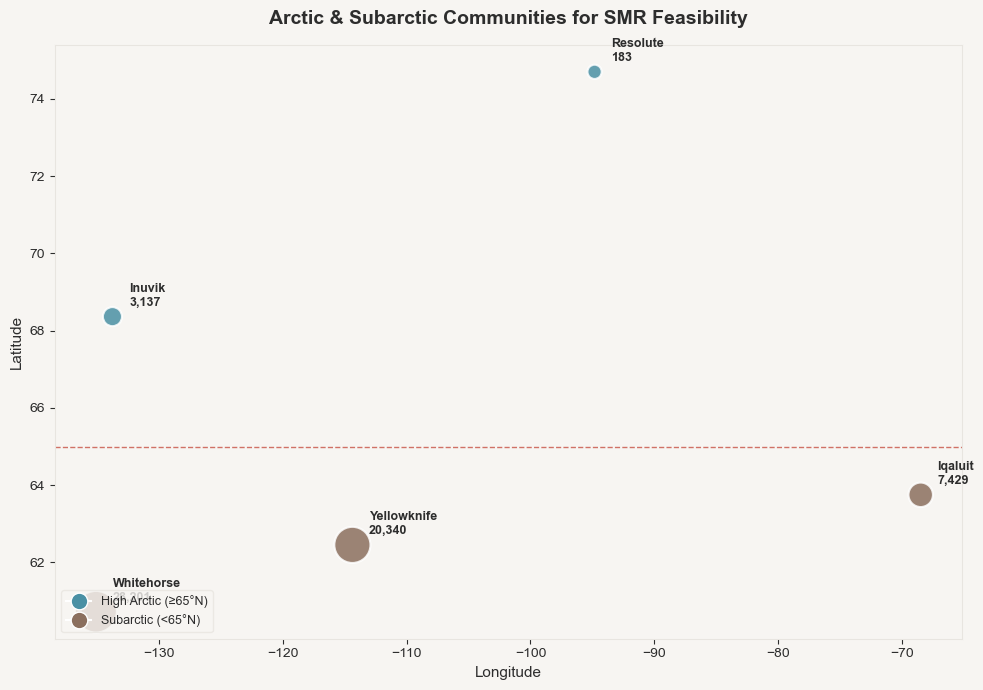

In [156]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Design System ──
COLORS = {
    'nuclear': '#0D7377',
    'nuclear_light': '#5BB5B5',
    'diesel': '#D4762C',
    'renewable': '#7BA05B',
    'high_arctic': '#4A90A4',
    'subarctic': '#8B6F5E',
    'background': '#F7F5F2',
    'text': '#2D2D2D',
    'grid': '#E8E5E0',
    'threshold': '#C0392B',
    'annotation': '#666666'
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'Calibri'],
    'text.color': COLORS['text'],
    'axes.labelcolor': COLORS['text'],
    'xtick.color': COLORS['text'],
    'ytick.color': COLORS['text'],
    'figure.facecolor': COLORS['background'],
    'axes.facecolor': COLORS['background'],
    'axes.edgecolor': COLORS['grid'],
    'axes.grid': False
})

# ── Chart 1: Community Map ──
fig, ax = plt.subplots(figsize=(10, 7))

zone_colors = sites['zone'].map({
    'High Arctic': COLORS['high_arctic'],
    'Subarctic': COLORS['subarctic']
})

# Bubble size scaled to population
sizes = sites['population'] / sites['population'].max() * 800 + 100

ax.scatter(
    sites['lon'], sites['lat'],
    s=sizes, c=zone_colors, alpha=0.85,
    edgecolors='white', linewidths=1.5, zorder=5
)

# Label each community
for _, row in sites.iterrows():
    ax.annotate(
        f"{row['community']}\n{row['population']:,}",
        (row['lon'], row['lat']),
        textcoords="offset points",
        xytext=(12, 8),
        fontsize=9,
        fontweight='bold',
        color=COLORS['text']
    )

# Threshold line at 65°N
ax.axhline(y=65, color=COLORS['threshold'], linestyle='--', linewidth=1, alpha=0.7)
ax.annotate('65°N — Arctic boundary', xy=(-140, 65.2),
            fontsize=8, fontstyle='italic', color=COLORS['annotation'])

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title('Arctic & Subarctic Communities for SMR Feasibility',
             fontsize=14, fontweight='bold', pad=15)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['high_arctic'],
           markersize=12, label='High Arctic (≥65°N)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['subarctic'],
           markersize=12, label='Subarctic (<65°N)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
          frameon=True, facecolor=COLORS['background'], edgecolor=COLORS['grid'])

plt.tight_layout()
fig.savefig("charts/01_community_map.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()

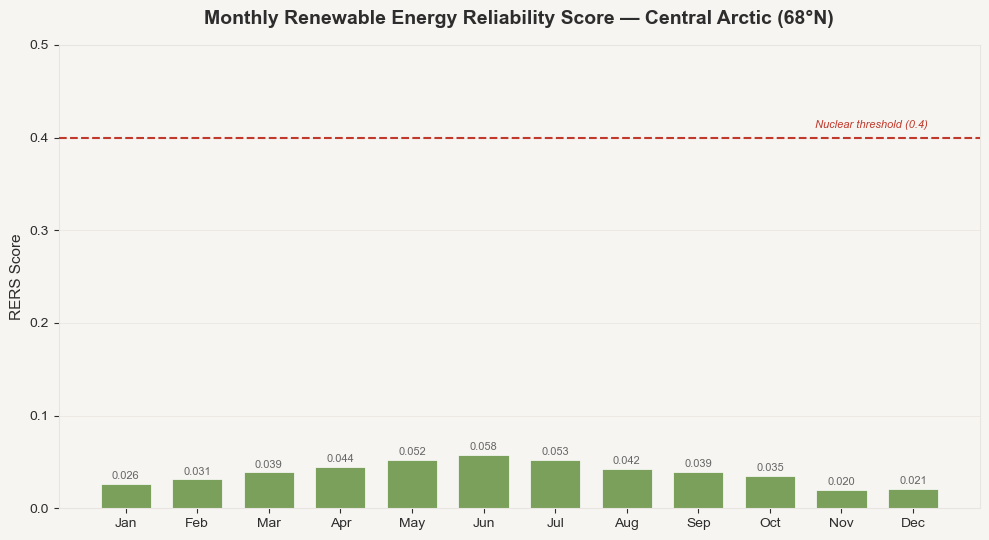

In [ ]:
# ── Chart 2: Monthly RERS ──
fig, ax = plt.subplots(figsize=(10, 5.5))

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_rers = climate.groupby("month")["RERS"].mean()

bars = ax.bar(
    month_names, monthly_rers.values,
    color=COLORS['renewable'], edgecolor='white', linewidth=0.5, width=0.7
)

# Threshold line
ax.axhline(y=NUCLEAR_THRESHOLD, color=COLORS['threshold'],
           linestyle='--', linewidth=1.5, zorder=10)
ax.annotate(f'Nuclear threshold ({NUCLEAR_THRESHOLD})',
            xy=(11.2, NUCLEAR_THRESHOLD + 0.01),
            fontsize=8, fontstyle='italic', color=COLORS['threshold'],
            ha='right')

# Data labels
for bar, val in zip(bars, monthly_rers.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color=COLORS['annotation'])

ax.set_ylabel('RERS Score', fontsize=11)
ax.set_title('Monthly Renewable Energy Reliability Score — Central Arctic (68°N)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 0.5)
ax.yaxis.grid(True, color=COLORS['grid'], linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig("charts/02_monthly_rers.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()

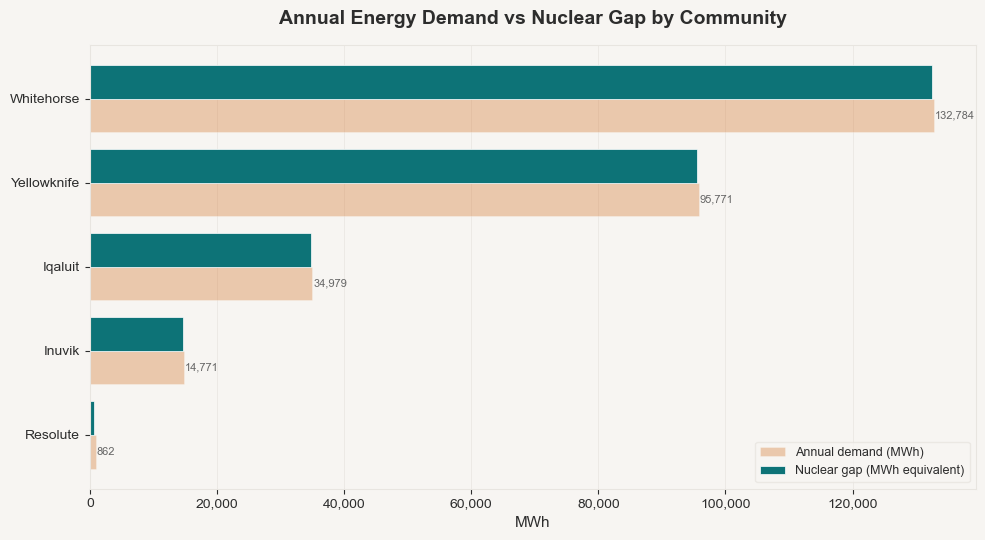

In [167]:
# ── Chart 3: Demand + Nuclear Gap ──
fig, ax = plt.subplots(figsize=(10, 5.5))

sorted_sites = sites.sort_values('annual_demand_mwh', ascending=True)
y_pos = range(len(sorted_sites))

# Annual demand bars
ax.barh(y_pos, sorted_sites['annual_demand_mwh'],
        color=COLORS['diesel'], alpha=0.35, edgecolor='white',
        linewidth=0.5, label='Annual demand (MWh)', height=0.4)

# Nuclear gap overlay (in MWh for same scale)
nuclear_gap_mwh = sorted_sites['nuclear_gap_mw'] * 8760
ax.barh([y + 0.4 for y in y_pos], nuclear_gap_mwh,
        color=COLORS['nuclear'], edgecolor='white',
        linewidth=0.5, label='Nuclear gap (MWh equivalent)', height=0.4)

ax.set_yticks([y + 0.2 for y in y_pos])
ax.set_yticklabels(sorted_sites['community'], fontsize=10)
ax.set_xlabel('MWh', fontsize=11)
ax.set_title('Annual Energy Demand vs Nuclear Gap by Community',
             fontsize=14, fontweight='bold', pad=15)
ax.xaxis.grid(True, color=COLORS['grid'], linewidth=0.5)
ax.set_axisbelow(True)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Data labels
for i, (_, row) in enumerate(sorted_sites.iterrows()):
    ax.text(row['annual_demand_mwh'] + 200, i,
            f"{row['annual_demand_mwh']:,.0f}", va='center', fontsize=8,
            color=COLORS['annotation'])

ax.legend(loc='lower right', fontsize=9,
          frameon=True, facecolor=COLORS['background'], edgecolor=COLORS['grid'])

plt.tight_layout()
fig.savefig("charts/03_demand_nuclear_gap.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()

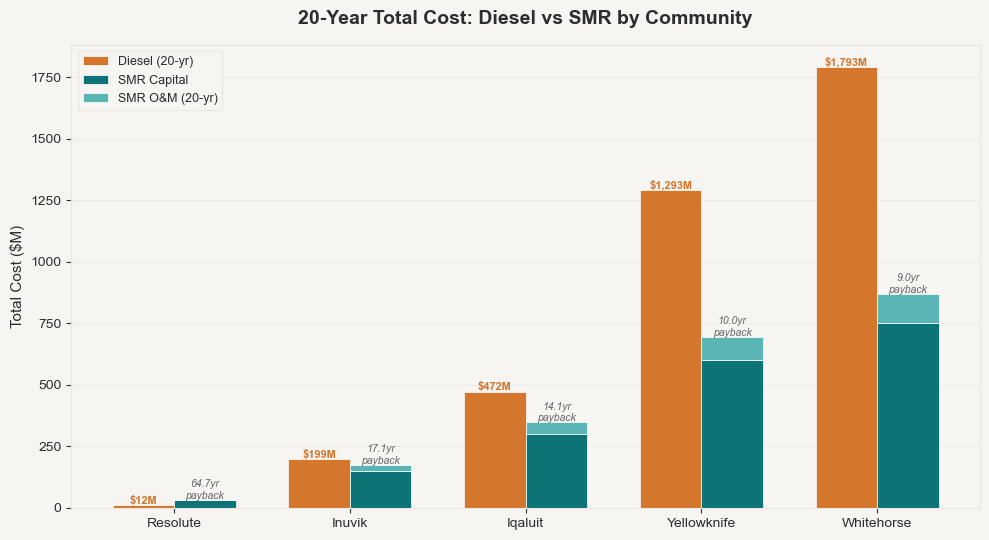

In [171]:
# ── Chart 4: Diesel vs SMR 20-Year Cost ──
fig, ax = plt.subplots(figsize=(10, 5.5))

sorted_sites = sites.sort_values('diesel_20yr_total_m', ascending=True)
communities = sorted_sites['community'].tolist()
x = np.arange(len(communities))
width = 0.35

# Diesel bars
diesel_bars = ax.bar(x - width/2, sorted_sites['diesel_20yr_total_m'],
                      width, color=COLORS['diesel'], edgecolor='white',
                      linewidth=0.5, label='Diesel (20-yr)')

# SMR bars — stacked capital + O&M
smr_om_total = sorted_sites['smr_annual_om_m'] * SMR_LIFESPAN_YEARS
smr_capital = sorted_sites['smr_capital_cost_m']

ax.bar(x + width/2, smr_capital, width,
       color=COLORS['nuclear'], edgecolor='white', linewidth=0.5,
       label='SMR Capital')
ax.bar(x + width/2, smr_om_total, width,
       bottom=smr_capital, color=COLORS['nuclear_light'],
       edgecolor='white', linewidth=0.5, label='SMR O&M (20-yr)')

# Payback annotations
for i, (_, row) in enumerate(sorted_sites.iterrows()):
    ax.annotate(f"{row['smr_payback_years']}yr\npayback",
                xy=(i + width/2, row['smr_20yr_total_m'] + 5),
                ha='center', fontsize=7.5, fontstyle='italic',
                color=COLORS['annotation'])

# Data labels on diesel bars
for i, (_, row) in enumerate(sorted_sites.iterrows()):
    ax.text(i - width/2, row['diesel_20yr_total_m'] + 5,
            f"${row['diesel_20yr_total_m']:,.0f}M",
            ha='center', fontsize=8, color=COLORS['diesel'], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(communities, fontsize=10)
ax.set_ylabel('Total Cost ($M)', fontsize=11)
ax.set_title('20-Year Total Cost: Diesel vs SMR by Community',
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.grid(True, color=COLORS['grid'], linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(loc='upper left', fontsize=9,
          frameon=True, facecolor=COLORS['background'], edgecolor=COLORS['grid'])

plt.tight_layout()
fig.savefig("charts/04_cost_comparison.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()

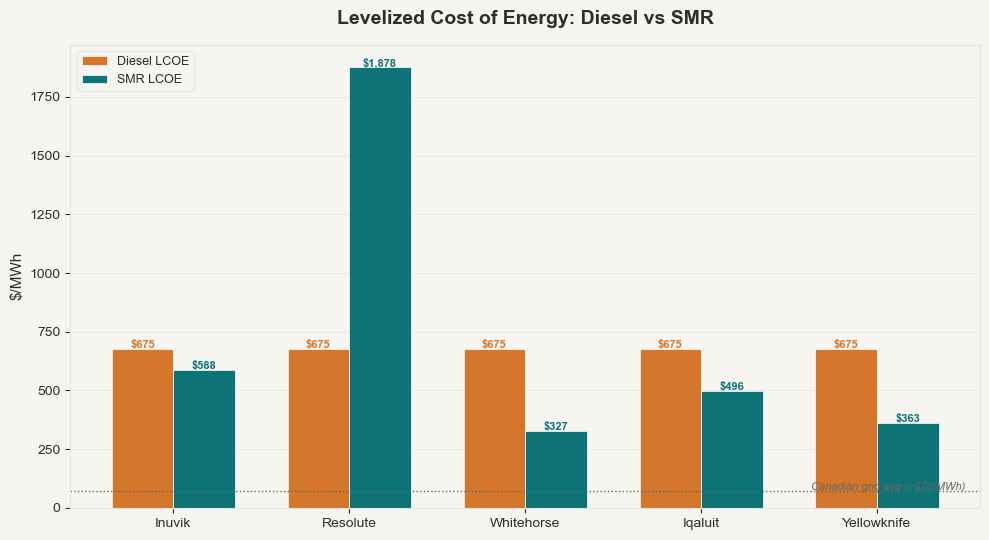

In [174]:
# ── Chart 5: LCOE Comparison ──
fig, ax = plt.subplots(figsize=(10, 5.5))

sorted_sites = sites.sort_values('diesel_lcoe', ascending=True)
communities = sorted_sites['community'].tolist()
x = np.arange(len(communities))
width = 0.35

ax.bar(x - width/2, sorted_sites['diesel_lcoe'], width,
       color=COLORS['diesel'], edgecolor='white', linewidth=0.5,
       label='Diesel LCOE')
ax.bar(x + width/2, sorted_sites['smr_lcoe'], width,
       color=COLORS['nuclear'], edgecolor='white', linewidth=0.5,
       label='SMR LCOE')

# Canadian grid average reference
ax.axhline(y=70, color=COLORS['annotation'], linestyle=':', linewidth=1)
ax.annotate('Canadian grid avg (~$70/MWh)', xy=(len(communities)-0.5, 75),
            fontsize=8, fontstyle='italic', color=COLORS['annotation'], ha='right')

# Data labels
for i, (_, row) in enumerate(sorted_sites.iterrows()):
    ax.text(i - width/2, row['diesel_lcoe'] + 5,
            f"${row['diesel_lcoe']:,.0f}", ha='center', fontsize=8,
            color=COLORS['diesel'], fontweight='bold')
    ax.text(i + width/2, row['smr_lcoe'] + 5,
            f"${row['smr_lcoe']:,.0f}", ha='center', fontsize=8,
            color=COLORS['nuclear'], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(communities, fontsize=10)
ax.set_ylabel('$/MWh', fontsize=11)
ax.set_title('Levelized Cost of Energy: Diesel vs SMR',
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.grid(True, color=COLORS['grid'], linewidth=0.5)
ax.set_axisbelow(True)

ax.legend(loc='upper left', fontsize=9,
          frameon=True, facecolor=COLORS['background'], edgecolor=COLORS['grid'])

plt.tight_layout()
fig.savefig("charts/05_lcoe_comparison.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()

In [175]:
print(sites[["community", "population", "reactor_mw", "smr_units_needed", "annual_demand_mwh", "smr_lcoe"]])

     community  population  reactor_mw  smr_units_needed  annual_demand_mwh  \
0      Iqaluit        7429        5.16                 2         34979.4465   
1       Inuvik        3137        2.16                 1         14770.5645   
2     Resolute         183        0.10                 1           861.6555   
3  Yellowknife       20340       14.18                 4         95770.8900   
4   Whitehorse       28201       19.67                 5        132784.4085   

      smr_lcoe  
0   496.440102  
1   587.831291  
2  1878.082366  
3   362.640464  
4   326.943506  


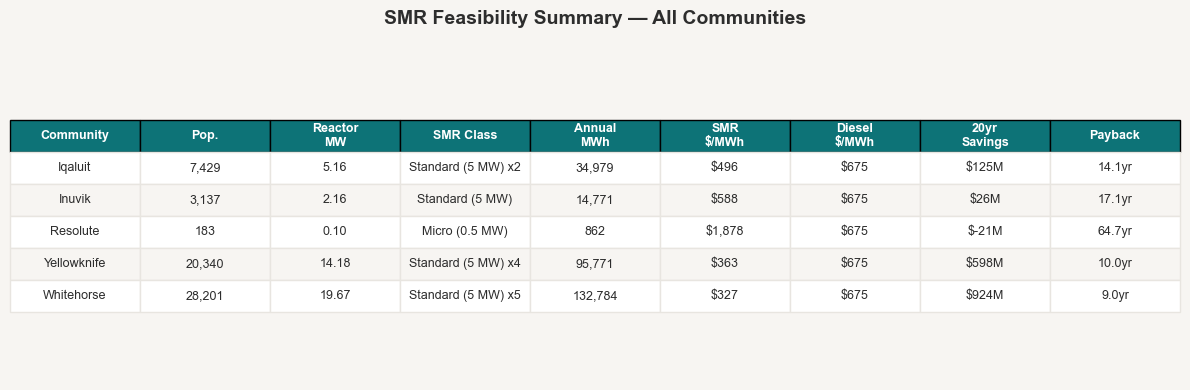

In [176]:
# ── Chart 6: Summary Dashboard Table ──
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = []
for _, row in sites.iterrows():
    table_data.append([
        row['community'],
        f"{row['population']:,}",
        f"{row['reactor_mw']:.2f}",
        row['smr_class'],
        f"{row['annual_demand_mwh']:,.0f}",
        f"${row['smr_lcoe']:,.0f}",
        f"${row['diesel_lcoe']:,.0f}",
        f"${row['savings_20yr_m']:,.0f}M",
        f"{row['smr_payback_years']}yr"
    ])

col_labels = ['Community', 'Pop.', 'Reactor\nMW', 'SMR Class',
              'Annual\nMWh', 'SMR\n$/MWh', 'Diesel\n$/MWh',
              '20yr\nSavings', 'Payback']

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.8)

# Style header row
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#0D7377')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(table_data) + 1):
    color = '#F7F5F2' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)
        table[i, j].set_edgecolor('#E8E5E0')

ax.set_title('SMR Feasibility Summary — All Communities',
             fontsize=14, fontweight='bold', pad=20, color='#2D2D2D')

plt.tight_layout()
fig.savefig("charts/06_summary_table.png", dpi=300, bbox_inches='tight', facecolor='#F7F5F2')
plt.show()